# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Libraries imported successfully!
Pandas version: 3.0.3
NumPy version: 2.4.6
Matplotlib version: 3.11.0


#  Load Data

**Load dataset**

In [5]:
df = pd.read_csv('../project1_online_sales/data/Online Sales Data.csv', sep=';')

**First look at data**

In [6]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (240, 9)

First 5 rows:


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,01.01.2024,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,02.01.2024,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,03.01.2024,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,04.01.2024,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,05.01.2024,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


# Data Info

**General info about dataset**

In [7]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    240 non-null    int64
 1   Date              240 non-null    str  
 2   Product Category  240 non-null    str  
 3   Product Name      240 non-null    str  
 4   Units Sold        240 non-null    int64
 5   Unit Price        240 non-null    str  
 6   Total Revenue     240 non-null    str  
 7   Region            240 non-null    str  
 8   Payment Method    240 non-null    str  
dtypes: int64(2), str(7)
memory usage: 17.0 KB
None

=== Missing Values ===
Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64

=== Basic Statistics ===
       Transaction ID  Units Sold
count       240.00000  240.000000
mean      

#  Preprocessing

**Convert Date column to datetime**

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
df['Date'].head()

0   2024-01-01
1   2024-01-02
2   2024-01-03
3   2024-01-04
4   2024-01-05
Name: Date, dtype: datetime64[us]

**Clean Total Revenue column**

In [12]:
df['Total Revenue'] = pd.to_numeric(df['Total Revenue'], errors='coerce')
df['Total Revenue'].head()

0    1999.98
1     499.99
2     209.97
3      63.96
4      89.99
Name: Total Revenue, dtype: float64

**Drop missing values**

In [16]:
df.dropna(inplace=True)
df.isnull().sum()

Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64

**Extract month and year from date**

In [18]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month_Name'] = df['Date'].dt.strftime('%B')

In [21]:
print(f"Final shape: {df.shape}")
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Final shape: (235, 12)

Date range: 2024-01-01 00:00:00 to 2024-08-27 00:00:00


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Month,Year,Month_Name
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card,1,2024,January
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal,1,2024,January
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card,1,2024,January
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card,1,2024,January
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal,1,2024,January


# Statistical Analysis

**Calculate mean and standard deviation of Total Revenue**

In [23]:
mean_revenue = df['Total Revenue'].mean()
std_revenue = df['Total Revenue'].std()
total_revenue = df['Total Revenue'].sum()

print(f"Mean Revenue:               ${mean_revenue:,.2f}")
print(f"Standard Deviation:         ${std_revenue:,.2f}")
print(f"Total Revenue:              ${total_revenue:,.2f}")
print(f"Max Single Transaction:     ${df['Total Revenue'].max():,.2f}")
print(f"Min Single Transaction:     ${df['Total Revenue'].min():,.2f}")

Mean Revenue:               $342.51
Standard Deviation:         $488.68
Total Revenue:              $80,488.85
Max Single Transaction:     $3,899.99
Min Single Transaction:     $15.00


#  Top 10 Products

**Find top 10 best selling products by units sold**

In [26]:
top10_products = df.groupby('Product Name')['Units Sold'].sum().sort_values(ascending=False).head(10)
print("=== Top 10 Best Selling Products ===",top10_products)


=== Top 10 Best Selling Products === Product Name
Hanes ComfortSoft T-Shirt                           10
The Catcher in the Rye by J.D. Salinger              7
Gap Essential Crewneck T-Shirt                       6
Yeti Rambler Tumbler                                 6
Spalding NBA Street Basketball                       6
Nike Air Force 1                                     6
The Girl with the Dragon Tattoo by Stieg Larsson     5
Forever 21 Graphic Tee                               5
Calvin Klein Boxer Briefs                            5
The Silent Patient by Alex Michaelides               5
Name: Units Sold, dtype: int64


#  Monthly Sales Trend Chart

**Monthly sales trend**

In [28]:
monthly_revenue = df.groupby(['Year', 'Month', 'Month_Name'])['Total Revenue'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values(['Year', 'Month'])
monthly_revenue

,Year,Month,Month_Name,Total Revenue
0,2024,1,January,14548.32
1,2024,2,February,10803.37
2,2024,3,March,12849.24
3,2024,4,April,12445.19
4,2024,5,May,8419.19
5,2024,6,June,7355.05
6,2024,7,July,6797.08
7,2024,8,August,7271.41


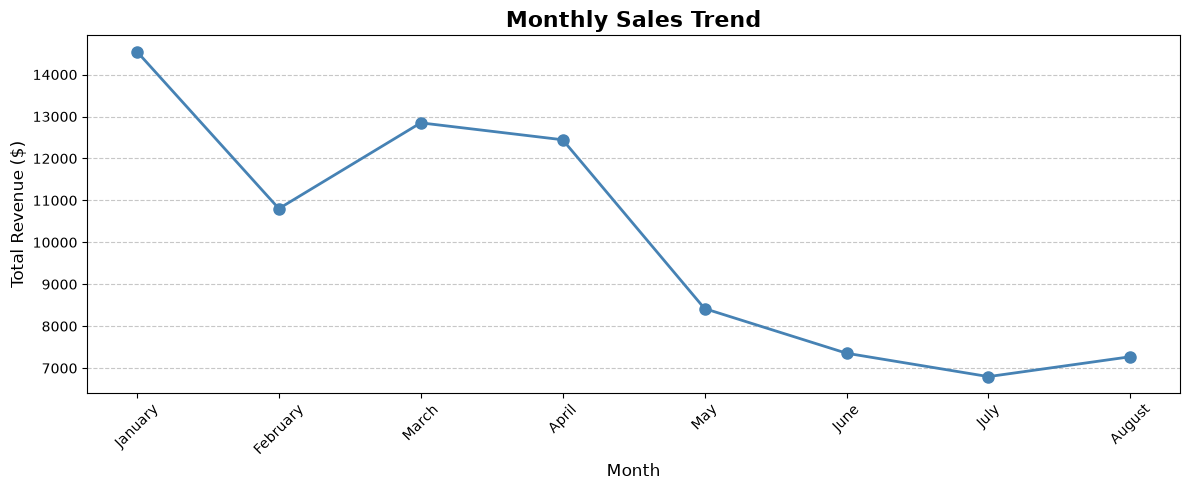

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['Month_Name'], monthly_revenue['Total Revenue'], 
         marker='o', linewidth=2, color='steelblue', markersize=8)

plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../project1_online_sales/monthly_sales_trend.png', dpi=150)
plt.show()

# Top 10 Products Bar Chart

**Top 10 best selling products bar chart**

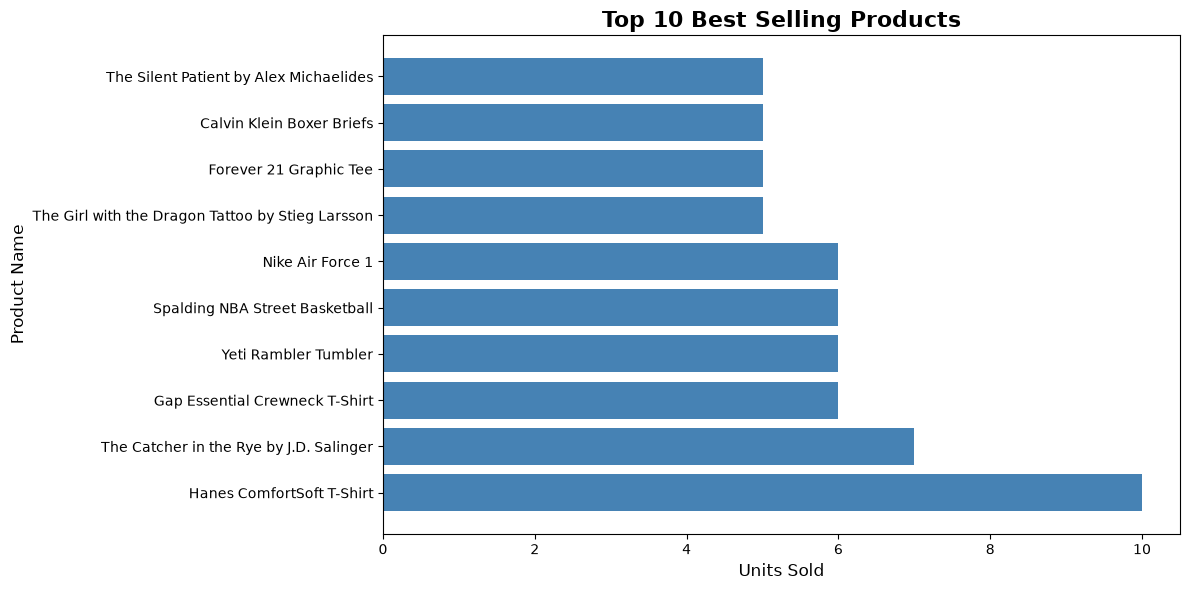

In [40]:
plt.figure(figsize=(12, 6))
plt.barh(top10_products.index, top10_products.values, color='steelblue')

plt.title('Top 10 Best Selling Products', fontsize=16, fontweight='bold')
plt.xlabel('Units Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.savefig('../project1_online_sales/top10_products.png', dpi=150)
plt.show()

**Add value labels on bars**

C:\Users\Danesh Computer\AppData\Local\Temp\ipykernel_25464\3989103123.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


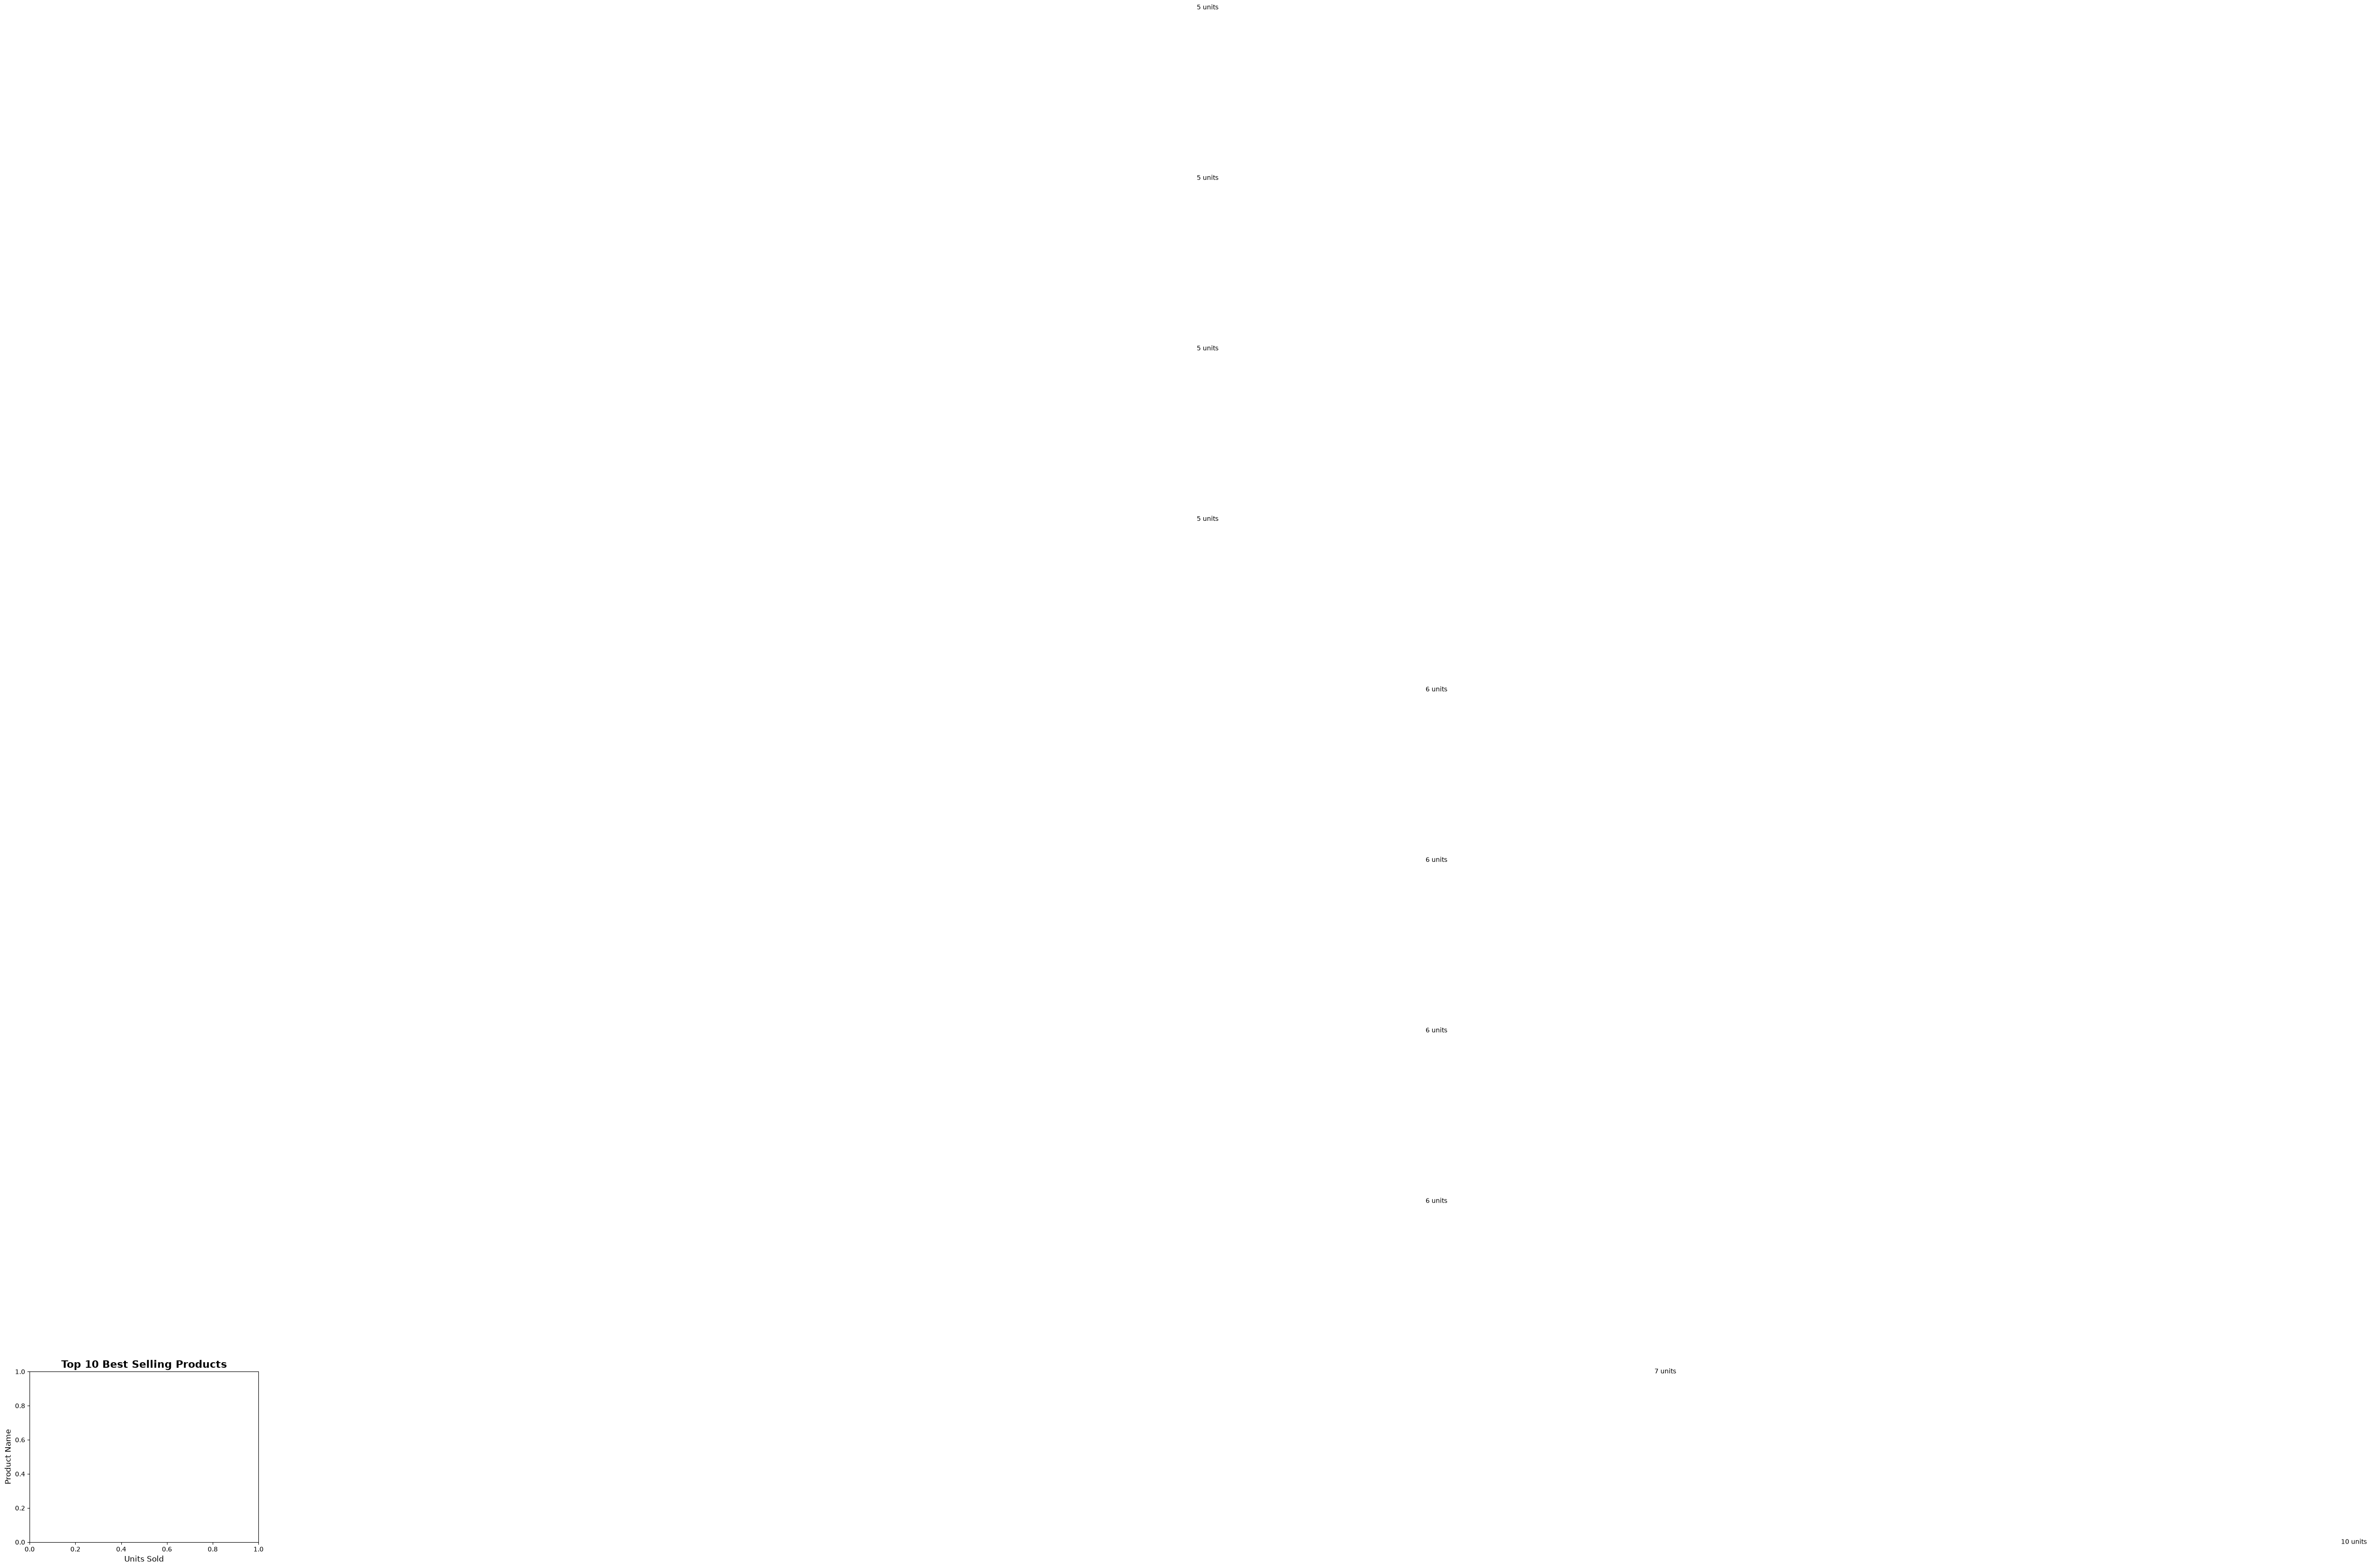